In [1]:
import requests
import time
import matplotlib.pyplot as plt

In [2]:
family_url = "http://localhost/orbit_families/get_families?filter_groups=[{%22log_op%22:%22NONE%22,%20%22filters%22:[{%22field%22:%22lib_point%22,%22op%22:%22like%22,%22value%22:%22L1%22}]},{%22log_op%22:%22OR%22,%22filters%22:[{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22L%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22V%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22L.2P1%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22L.3P1%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22L.4P1%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22L.2P1.2P1%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22L.2P1.3P1%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22L.2P1.3P2%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22H.2P1%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22H.2P2%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22H.2P3%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22H.3P1%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22H.3P2%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22H.3P3%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22H.4P1%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22Q%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22H_s%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22H_n%22}]}]"
map_url = "http://localhost/orbit_view/get_map?filter_groups=[{%22log_op%22:%22NONE%22,%20%22filters%22:[{%22field%22:%22lib_point%22,%22op%22:%22like%22,%22value%22:%22L1%22}]},{%22log_op%22:%22OR%22,%22filters%22:[{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22L%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22V%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22L.2P1%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22L.3P1%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22L.4P1%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22L.2P1.2P1%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22L.2P1.3P1%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22L.2P1.3P2%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22H.2P1%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22H.2P2%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22H.2P3%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22H.3P1%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22H.3P2%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22H.3P3%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22H.4P1%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22Q%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22H_s%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22H_n%22}]}]"
near_sec_url = "http://localhost/orbit_view/get_nearest_orbit?x=0&z=0"
trajectory_one_orbit_url = "http://localhost/trajectory_points/get_chunk?filter_groups=[{%22log_op%22:%22NONE%22,%20%22filters%22:[{%22field%22:%22orbit_id%22,%22op%22:%22==%22,%20%22value%22:%201}]}]"
sec_by_cj_url = "http://localhost/orbit_poincare_view/get_by_cj?filter_groups=[{%22log_op%22:%22NONE%22,%20%22filters%22:[{%22field%22:%22orbit_id%22,%20%22op%22:%22==%22,%20%22value%22:%221%22},{%22field%22:%22plane%22,%20%22op%22:%22==%22,%20%22value%22:%22y%20=%200%22}]}]&rate=0.0001"
next_orbit_url = "http://localhost/orbit_view/get_next_orbit?lib_point=L1&family_tag=H_s&id=1"
prev_orbit_url = "http://localhost/orbit_view/get_prev_orbit?lib_point=L1&family_tag=H_s&id=1"
fam_param_url = "http://localhost/orbit_view/get_family_param?lib_point=L1&family_tag=L&param_name_x=t&param_name_y=cj&param_name_z=ax"
Broucke_url = "http://localhost/orbit_view/get_Broucke?filter_groups=[{%22log_op%22:%22AND%22,%20%22filters%22:[{%22field%22:%22lib_point%22,%20%22op%22:%22like%22,%20%22value%22:%22L1%22},%20%20%20%20%20%20{%22field%22:%22family_tag%22,%20%22op%22:%22like%22,%20%22value%22:%22L%22}]}]"


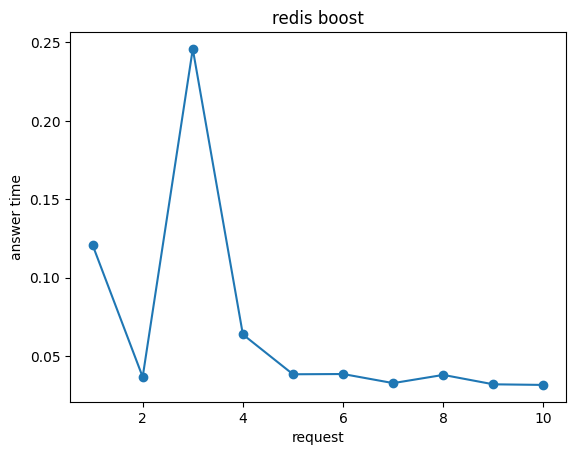

In [ ]:
def test_map():
    times = []
    url= "http://localhost/orbit_view/get_map?filter_groups=[{%22log_op%22:%22NONE%22,%20%22filters%22:[{%22field%22:%22lib_point%22,%22op%22:%22like%22,%22value%22:%22L1%22}]},{%22log_op%22:%22OR%22,%22filters%22:[{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22L%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22V%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22L.2P1%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22L.3P1%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22L.4P1%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22L.2P1.2P1%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22L.2P1.3P1%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22L.2P1.3P2%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22H.2P1%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22H.2P2%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22H.2P3%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22H.3P1%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22H.3P2%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22H.3P3%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22H.4P1%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22Q%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22H_s%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22H_n%22}]}]"
    for _ in range(10):
        start = time.time()
        response = requests.get()
        times.append(time.time() - start)
    return times

if __name__ == "__main__":
    count_request = [i for i in range(1, 11)]
    times = test_map()
    plt.plot(count_request, times, "o-")
    plt.xlabel("request")
    plt.ylabel("answer time")
    plt.title("redis boost")

In [ ]:
url = "http://localhost/orbit_view/get_map?filter_groups=[{%22log_op%22:%22NONE%22,%20%22filters%22:[{%22field%22:%22lib_point%22,%22op%22:%22like%22,%22value%22:%22L1%22}]},{%22log_op%22:%22OR%22,%22filters%22:[{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22L%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22V%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22L.2P1%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22L.3P1%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22L.4P1%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22L.2P1.2P1%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22L.2P1.3P1%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22L.2P1.3P2%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22H.2P1%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22H.2P2%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22H.2P3%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22H.3P1%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22H.3P2%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22H.3P3%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22H.4P1%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22Q%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22H_s%22},{%22field%22:%22family_tag%22,%22op%22:%22like%22,%22value%22:%22H_n%22}]}]"
requests.get(url)я

<Response [200]>